In [6]:
%load_ext autoreload
%autoreload 2

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import calendar
from utilClassification import check_dist, optimize, model_performance, data_preparation, pca

In [8]:
plt.rcParams.update({'font.size': 10,
                     'axes.titlesize': 'medium',
                     'axes.grid': False})

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

## Part I Data Preparation

In [9]:
# Load data
landuse_information = pd.read_csv('data/landuse_information.csv')
hour_to_week_group = pd.read_csv('data/hour_to_week_group.csv',
                                 dtype = {'site_id': str, 'year': int, 'label': int})
locations = pd.read_csv('data/locations_combine_site.csv', dtype = {'site_id': str})

In [10]:
data_encoded = data_preparation(hour_to_week_group, landuse_information, trail_df = locations)

In [11]:
data_encoded.head()

,label,trail,colleges_2,entertainment_2,heavy industry_2,light industry_2,offices_2,others_2,recreation_2,retail_2,...,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022,year_2023
0,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
print(data_encoded.shape)

(732, 131)


## Part II EDA

In [9]:
data_encoded.head()

,label,trail,colleges_2,entertainment_2,heavy industry_2,light industry_2,offices_2,others_2,recreation_2,retail_2,...,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022,year_2023
0,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# The size of each htw activity pattern group. 
# The groups is unbalanced, proportion ranged from 5.7% - 27.3%
data_encoded.label.value_counts(normalize = True).sort_index()

label
0    0.057377
1    0.233607
2    0.273224
3    0.166667
4    0.061475
5    0.118852
6    0.088798
Name: proportion, dtype: float64

### 1) Boxplot

NAICS
- colleges: 
    - Junior Colleges, Colleges, Universities, and Professional Schools, Technical and Trade Schools
- schools: 
    - elementary and secondary schools
- entertainment: 
    - Food and beverage retails, 
    - performing arts, spectator sports, 
    - amusement parks, gambling
- recreation: 
    - Museums, Historical Sites, and Similar Institutions
- travel & accommodation: 
    - Gasoline Stations and Fuel Dealers, 
    - Transit and Ground Passenger Transportation, Accommodation
- retail: 
    - All kinds of retailers
- heavy industry: 
    - Mining, Quarrying, and Oil and Gas Extraction, 
    - Utilities, 
    - Manufacturing
- light industry: 
    - Wholesale Trade, 
    - Transportation and Warehousing
- offices: 
    - construction, Information, 
    - Finance and Insurance, 
    - Real Estate and Rental and Leasing, 
    - Professional, Scientific, and Technical Services, Management of Companies and Enterprises, 
    - Administrative and Support and Waste Management and Remediation Services, 
    - Business Schools and Computer and Management Training, 
    - Educational Support Services
- others: 
    - Agriculture, Forestry, Fishing and Hunting


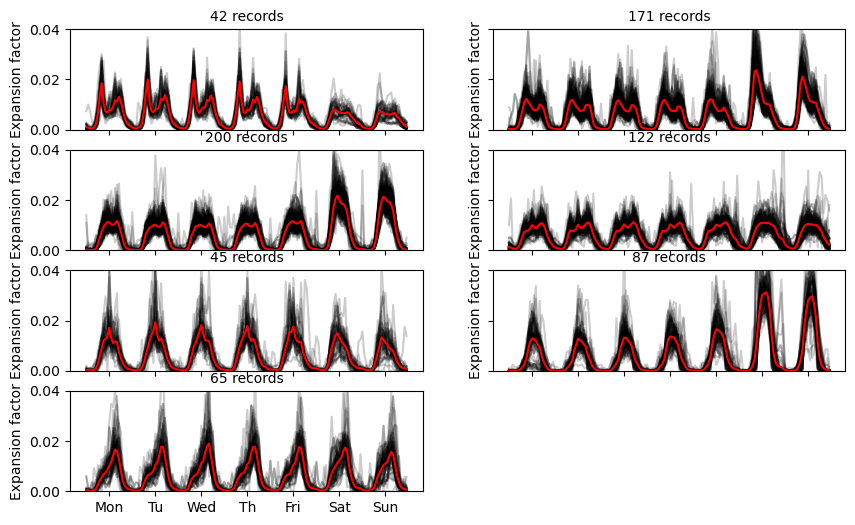

In [1]:
from IPython.display import Image
Image("htw.png")
# from left to right, top to bottom (cluster 0 to 6)

In [43]:
data_encoded.loc[:,['total_4', 'total_6', 'label']].groupby(['label']).describe()

total_4                                                            \
        count        mean         std   min   25%    50%    75%     max   
label                                                                     
0        42.0   34.000000   14.282857  12.0  25.0   39.0   45.0    55.0   
1       171.0   29.081871   35.745905   0.0   7.0   14.0   36.0   155.0   
2       200.0   55.690000  212.016245   0.0   4.0   15.0   45.0  2109.0   
3       122.0  403.581967  853.764051   0.0  58.0  110.0  289.0  3705.0   
4        45.0   82.044444   91.772930   0.0  22.0   52.0  112.0   359.0   
5        87.0   53.379310   57.008005   0.0   4.0   34.0   91.0   178.0   
6        65.0  120.584615  443.077691   0.0  18.0   44.0  112.0  3603.0   

      total_6                                                               
        count        mean          std   min     25%    50%    75%     max  
label                                                                       
0        42.0  129.071429   109.067979  63.0   65.00  105.0  164.0   492.0  
1       171.0   78.736842    77.383505   0.0   17.00   59.0   92.0   330.0  
2       200.0  128.455000   353.637520   0.0    9.75   56.0  170.0  3471.0  
3       122.0  770.049180  1529.152306   0.0  123.00  249.0  602.0  6573.0  
4        45.0  161.977778   186.768146   0.0   55.00   96.0  249.0   722.0  
5        87.0  100.310345    88.031484   0.0    9.00  138.0  184.5   230.0  
6        65.0  271.492308   805.322550   1.0   84.00  111.0  235.0  6573.0

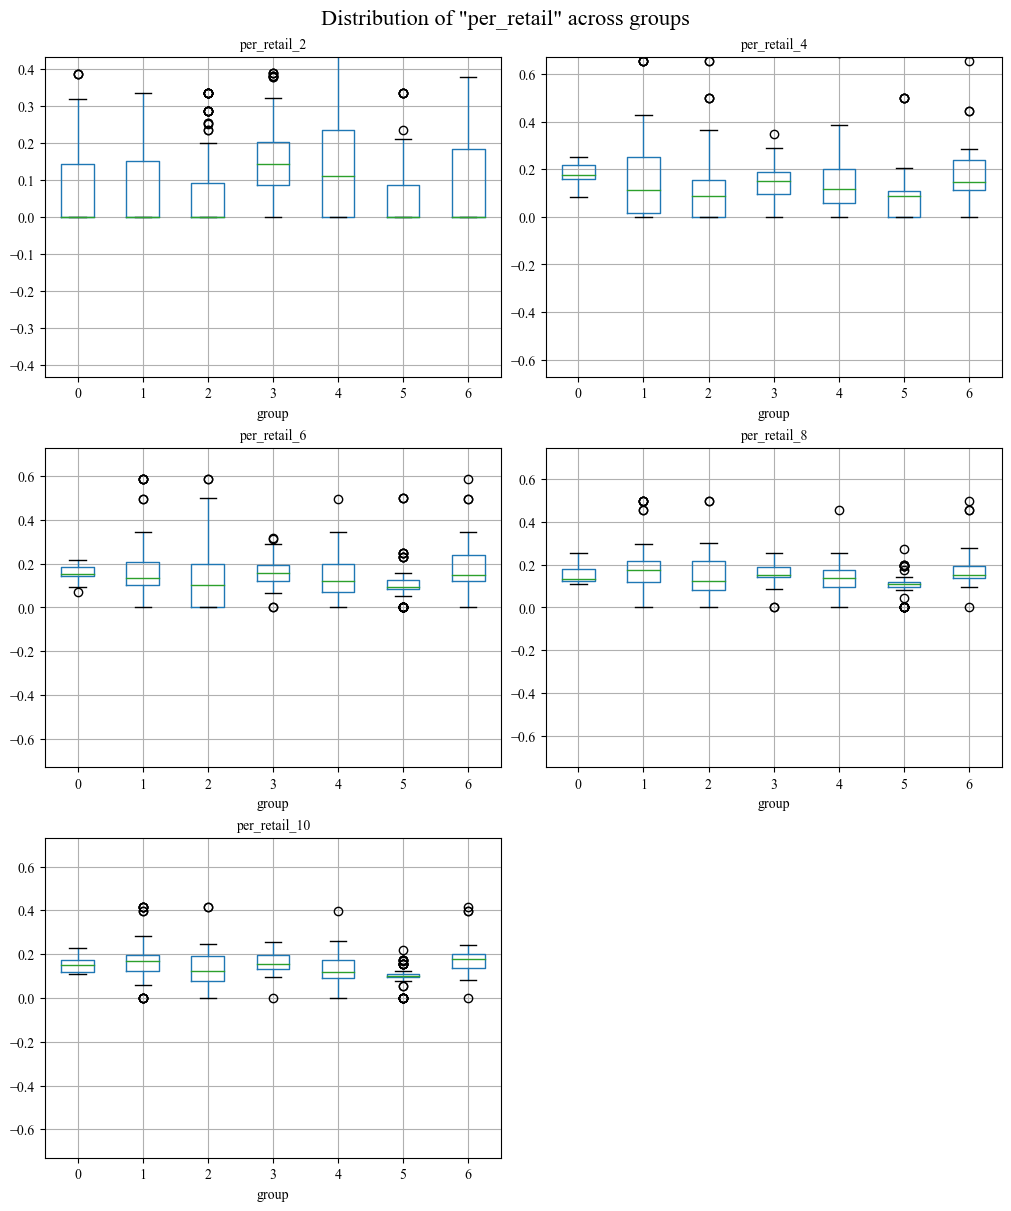

In [35]:

# variables: colleges, schools, 
#            entertainment, recreation, travel & accomodation, retail, 
#            heavy industry, light industry,  
#            offices, others, total
# Number of categories within 600 meters: LOW DENSITY - (Median < 100), MODERATE - (Median 100 ~ 200), HIGH DENSITY - (Median > 200)

# Cluster 0: (travel and retail) higher percentage of travel and accommodation with 400/600 meters, 
#                                higher percetage of retail within 400 meters, 
#                                total categories within 600 meters: (median = 105, mean = 129)
# Cluster 1: (low density with offices around) high percentage of offices within 400 meters, 
#                                              low number of total categories within 600 meters (median = 59, mean = 79)
# Cluster 2: (low density with agriculture/fishing industry) low percentage of light industry, 
#                                                            high percentage of other businesses within 400/600 meters, 
#                                                            low number total categoies within 600 meters (median = 56, mean = 128)
# Cluster 3: (dense mixed landuse with schools) schools/colleges nearby (600/800 meters), 
#                                               higher percentage of entertainment/retails within 400/600 meters, 
#                                               high number of total categories within 400/600 meters (median = 249, mean = 770)
# Cluster 4: (featuring offices) high percentage of offices within 400 meters
#                                total categories within 600 meters: (median = 96, mean = 162)
# Cluster 5: (recreation and offices) higher percentage of recreation/offices within 400/600 meters, no light industry
#                                     total categories within 600 meters: (median = 138, mean = 100)
# Cluster 6: (featuring heavy industry) higher percentage of heavy industry within 400/600/800 meters
#                                       total categories within 600 meters: (median = 111, mean = 271)
check_dist(data_encoded, 'per_retail')

### 2) Pearson correlation between variables

In [76]:
vars_ = ['colleges', 'entertainment', 'heavy industry', 'light industry', 
       'offices', 'others', 'recreation', 'retail', 'schools', 'travel & accommodation', 'total', 
       'per_colleges', 'per_entertainment', 'per_heavy industry', 'per_light industry',
       'per_offices', 'per_others', 'per_recreation', 'per_retail', 'per_schools', 'per_travel & accommodation']

<AxesSubplot:>

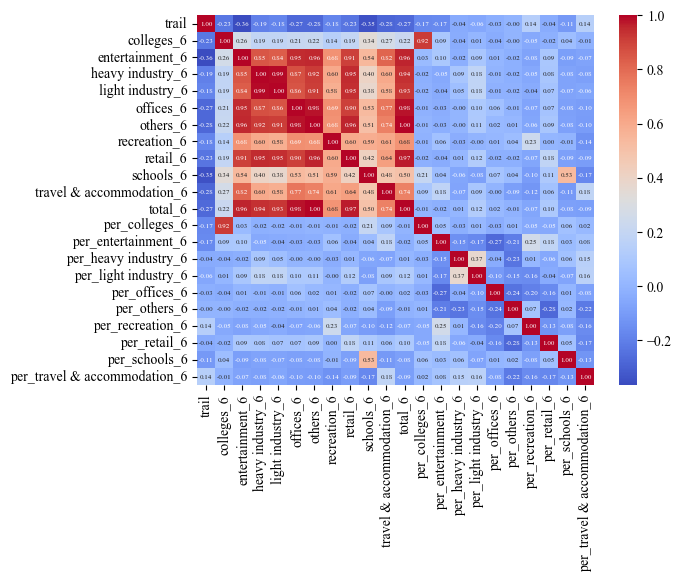

In [78]:
# colleges, schools, recreation use raw counts
suffix = '_6'
varnames = ['trail'] + [var + suffix for var in vars_]
plt.plot(figsize = (20, 20))
sns.heatmap(data_encoded[varnames].corr(), cmap = 'coolwarm', annot = True, fmt = '.2f', annot_kws = {'fontsize': 5})

In [45]:
# vars_ = ['colleges', 'entertainment', 'heavy industry', 'light industry', 
#       'offices', 'others', 'recreation', 'retail', 'schools', 'travel & accommodation', 'total']
# suffixes = ['_2', '_4', '_6', '_8', '_10']
# # The raw number of business within different buffers have strong correlation with each other
# # but the percentage of different business within different buffers does not 
# # have that strong correlation with each other
# var = vars_[1]
# varnames = ['trail'] + [var + sff for sff in suffixes] + ['per_' + var + sff for sff in suffixes]
# plt.plot(figsize = (10, 10))
# sns.heatmap(data_encoded[varnames].corr(), cmap = 'coolwarm', annot = True, fmt = '.2f', annot_kws = {'fontsize': 5})

### 3) ANOVA analysis

In [15]:
from sklearn.feature_selection import f_classif

f_statistic, p_values = f_classif(data_encoded.loc[:,'trail':], data_encoded['label'])
anova = pd.DataFrame({'variable':data_encoded.columns[1:], 'p_values': p_values}).sort_values(by = 'p_values')

In [36]:
# Variables with high correlation with label

# trail

# entertainment_2, travel & accomodation_4, per_light industry_2, per_others_2, schools_8, 
# recreation_8, pre_retail_10, heavy_industry_10, colleges_10, total_10, offices_4

# covid_pre-covid, year_group_2223, covid_pot-covid, year_group_171819, year_2023, year_group_1314, year_2022, year_2018

anova[anova.p_values <= 0.05].iloc[100:110]

,variable,p_values
123,year_2022,0.018012
80,per_offices_6,0.018773
94,per_schools_8,0.028579
119,year_2018,0.031065
70,per_offices_4,0.035503


### 4) PCA

In [37]:
from sklearn.decomposition import PCA

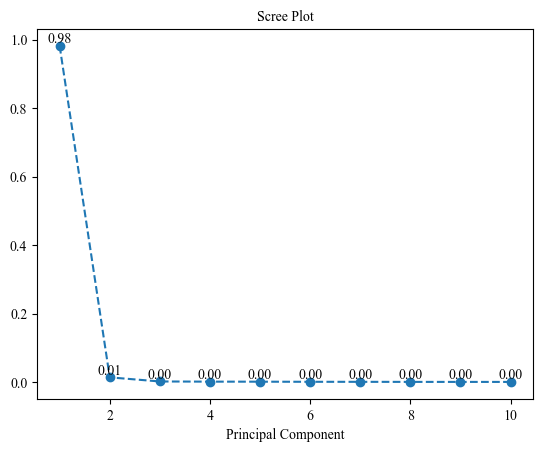

In [41]:
pca = pca(data_encoded)

In [42]:
pd.DataFrame({'varname': data_encoded.columns[1:], '1st_pca_coefficient': pca.components_[0, :]}).sort_values(by = '1st_pca_coefficient', ascending = False).head(90)[-10:]

,varname,1st_pca_coefficient
66,per_colleges_4,3.472704e-08
81,per_others_6,1.390165e-08
76,per_colleges_6,-1.411516e-09
56,per_colleges_2,-6.861908e-09
96,per_colleges_10,-1.093099e-08
86,per_colleges_8,-1.833119e-08
78,per_heavy industry_6,-1.871109e-08
114,year_2013,-2.890380e-08
88,per_heavy industry_8,-8.261413e-08
90,per_offices_8,-1.022340e-07


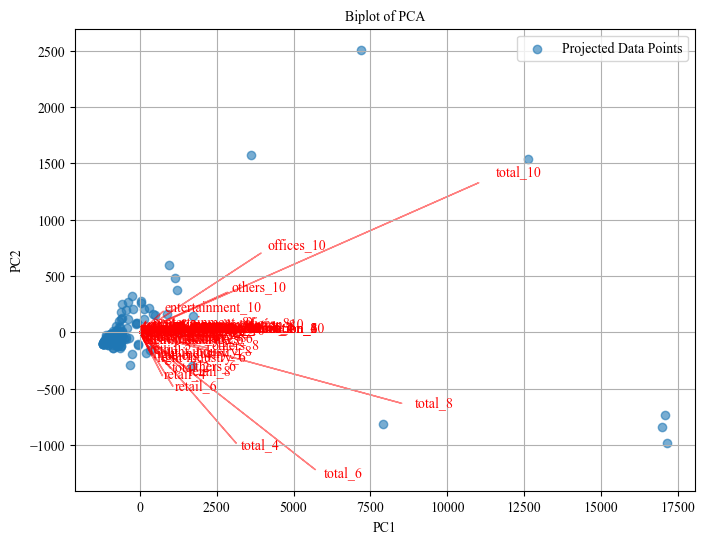

In [23]:
X_pca = pca.transform(X)

# Project data points on the 1st and 2nd principle components
plt.figure(figsize = (8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha = 0.6, label = 'Projected Data Points')

# pca.components_ is a 10 * n_feature matrix, values represent the loadings (coefficients) 
# of the features for each principal components

# max(X_pca[:, 0]) - scaling factor, maximum value along the first principal component axis
# adjust the length of arrow to match the data spread 

# Plot the loadings of each feature for the 1st and 2nd principle component
for i, feature in enumerate(X.columns):
    plt.arrow(0, 0, pca.components_[0, i]*max(X_pca[:, 0]), pca.components_[1, i]*max(X_pca[:, 1]),
              color = 'red', alpha = 0.5, head_width = 0.05)
    plt.text(pca.components_[0, i]*max(X_pca[:, 0])*1.05, pca.components_[1, i]*max(X_pca[:, 1])*1.05,
            feature, color = 'red')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot of PCA')
plt.grid()
plt.legend()
plt.show()

In [24]:
vars_

['colleges',
 'entertainment',
 'heavy industry',
 'light industry',
 'offices',
 'others',
 'recreation',
 'retail',
 'schools',
 'travel & accommodation',
 'total']

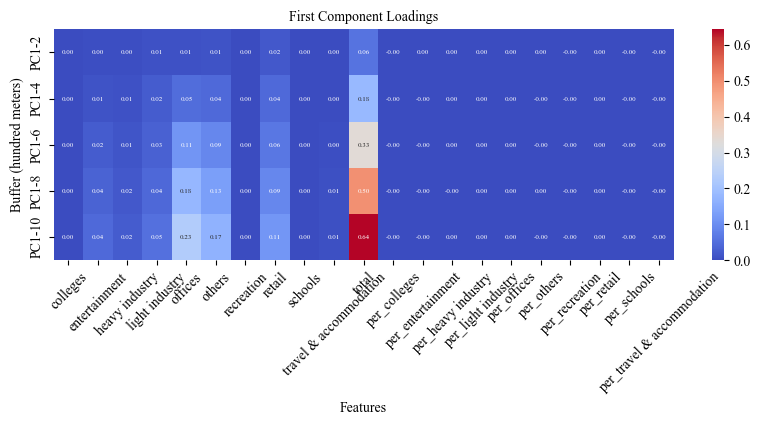

In [25]:
# the loadings/coefficient of each feature for the 1st principle component
# 'TOTAL's are the features that contribute most to the 1st principle component
# 'office_10', 'office_8', others_10', 'others_8' , 'retail_10' also contribute
first_comp = pd.DataFrame(np.array([pca.components_[0, X.columns.str.contains('2')],
                                    pca.components_[0, X.columns.str.contains('4')],
                                    pca.components_[0, X.columns.str.contains('6')],
                                    pca.components_[0, X.columns.str.contains('8')],
                                    pca.components_[0, X.columns.str.contains('10')]]),
                          columns = vars_ + ['per_' + var for var in vars_[:-1]],
                          index = ['PC1-2', 'PC1-4', 'PC1-6', 'PC1-8', 'PC1-10'])

plt.figure(figsize = (10, 3))
sns.heatmap(first_comp, cmap = 'coolwarm', annot = True, fmt = '.2f', annot_kws = {'fontsize': 5})
plt.xticks(rotation = 45)
plt.title('First Component Loadings')
plt.xlabel('Features')
plt.ylabel('Buffer (hundred meters)')
plt.show()

In [26]:
# buff = '2'
# mask = X.columns.str.contains(buff)
# loading_df = pd.DataFrame(pca.components_[:, mask], columns = X.columns[mask],
#                           index = [f'PC{i+1}' for i in range(pca.n_components)])
# plt.figure(figsize = (10, 8))
# sns.heatmap(loading_df, cmap = 'coolwarm', fmt = '.2f', annot = True, annot_kws = {'fontsize': 5})
# plt.show()

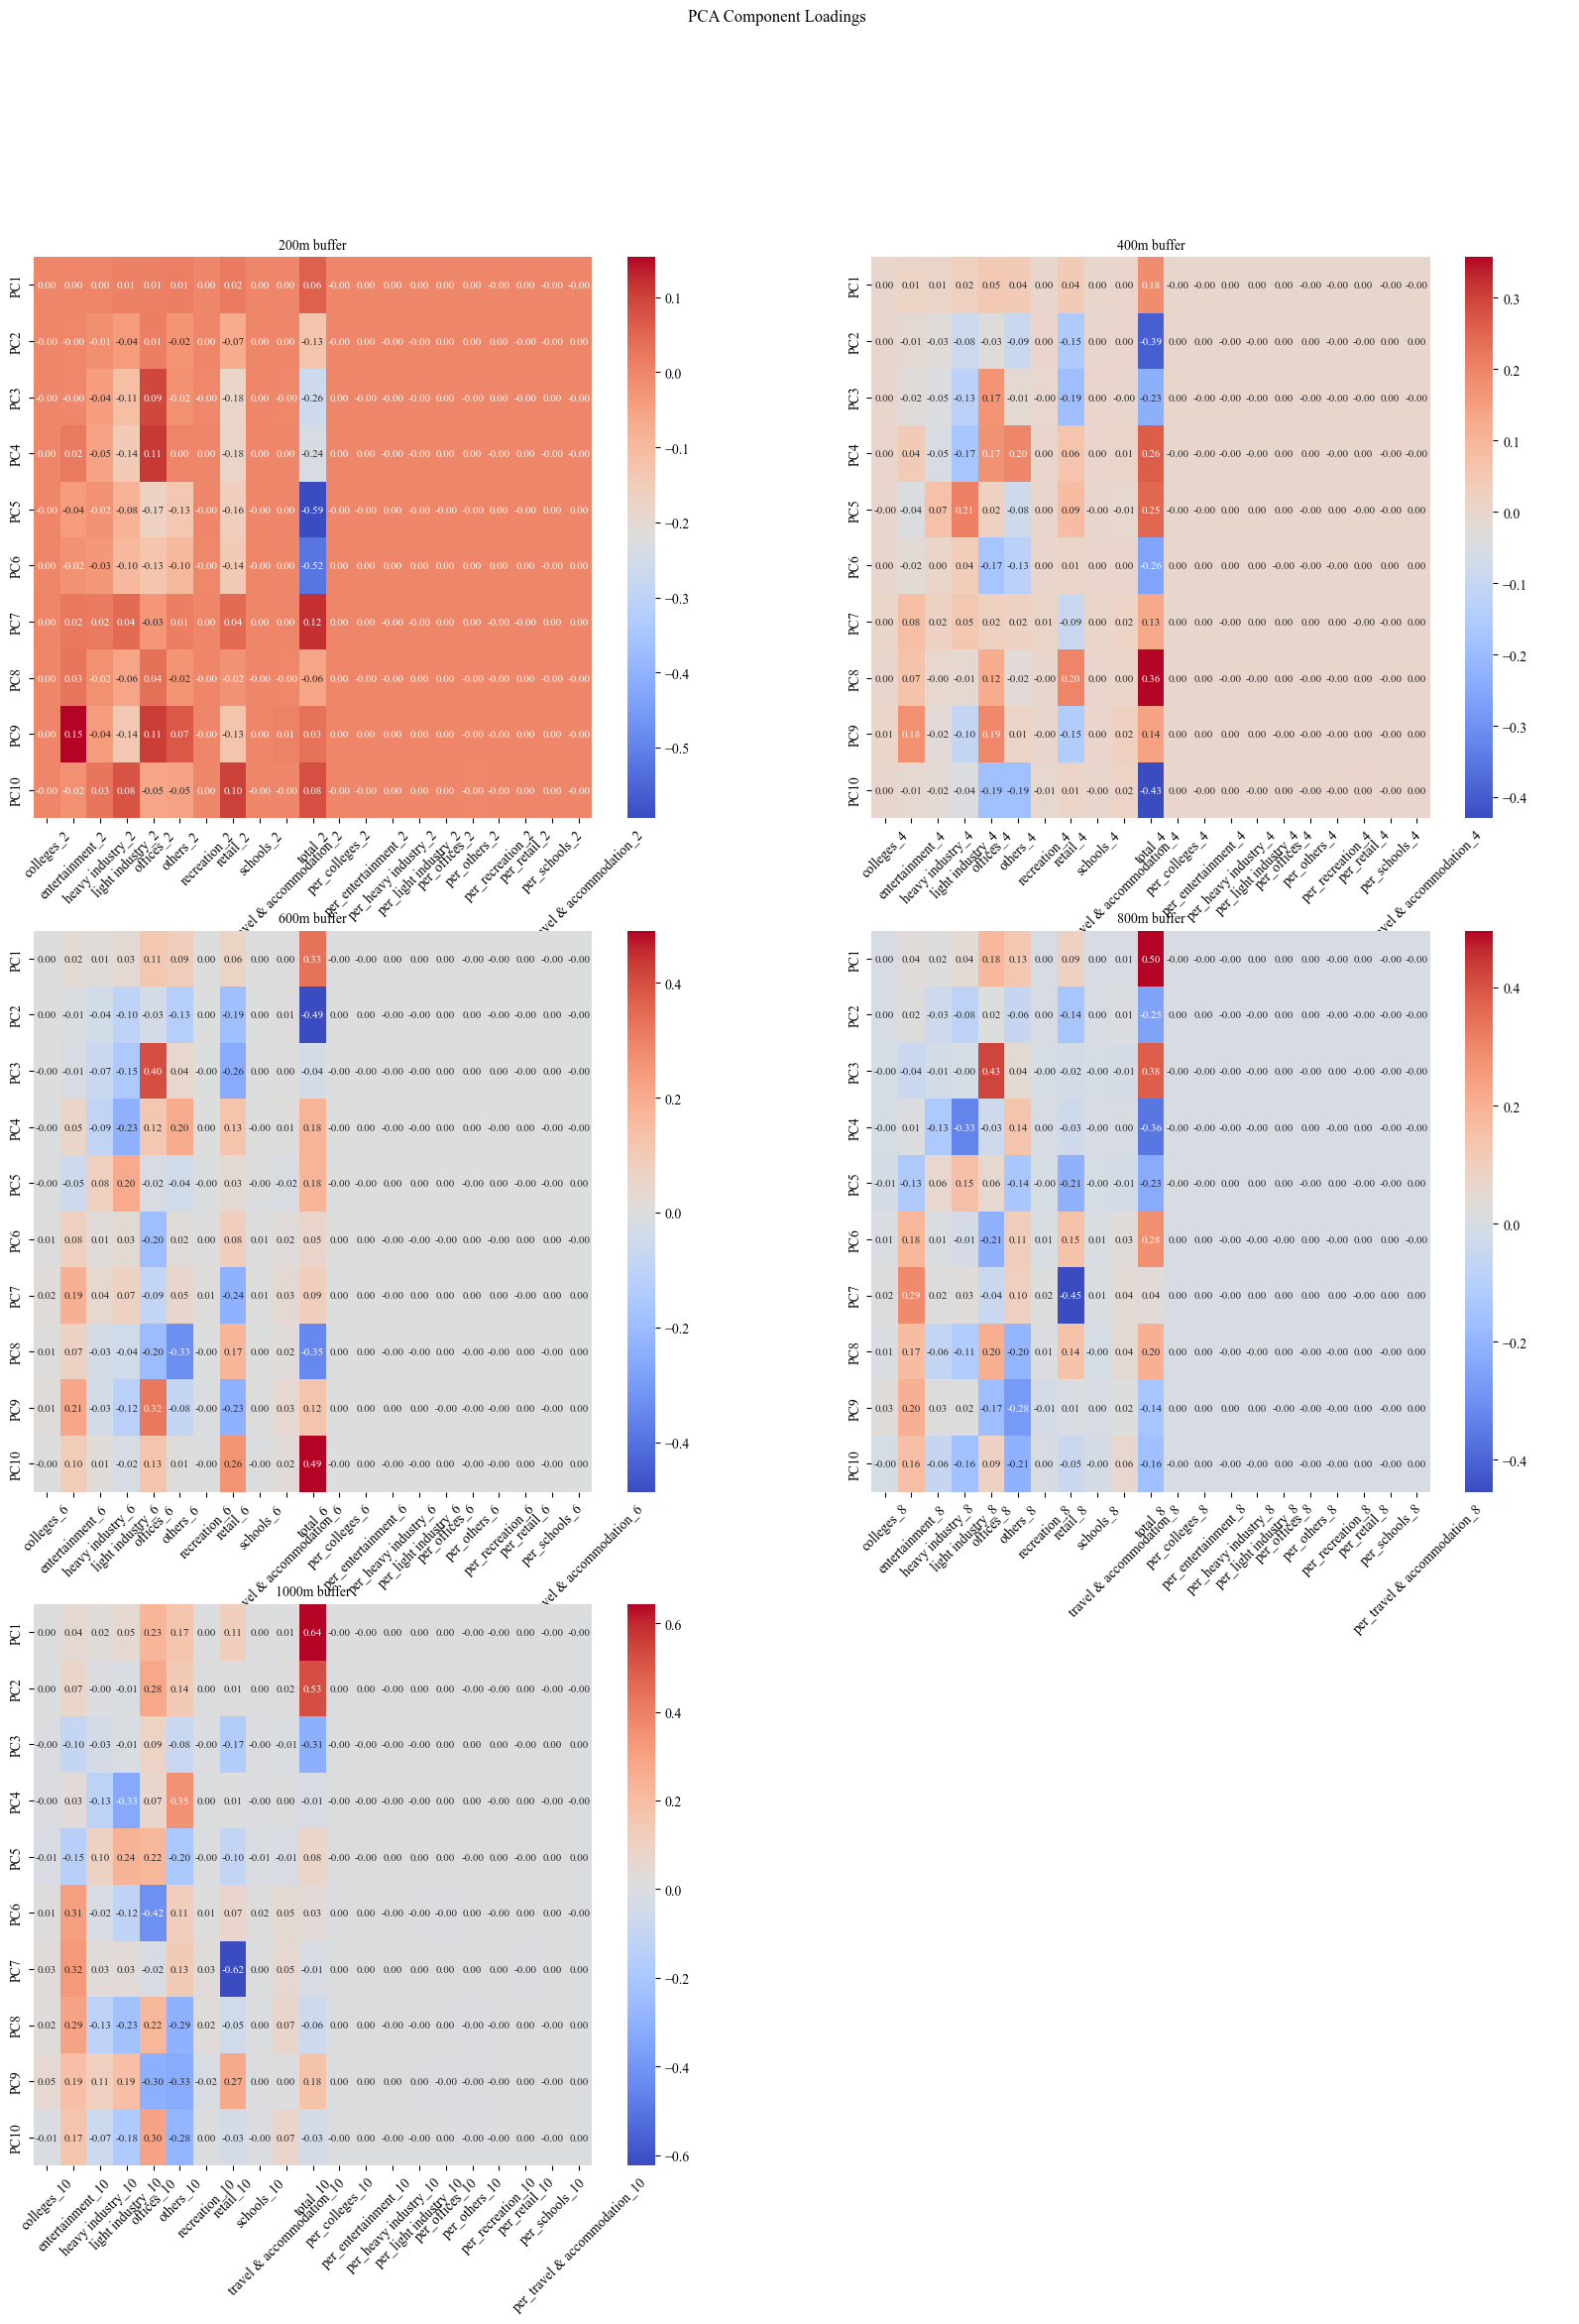

In [27]:
# The loading factors for each component for the top 10 principle components 
# 'Percentage XX' does not contribute much to the principle components
fig, axes = plt.subplots(3, 2, figsize = (20, 25))
buffer = ['2','4','6','8','10']
for i in range(5):
    mask = X.columns.str.contains(buffer[i])
    loading_df = pd.DataFrame(pca.components_[:, mask], columns = X.columns[mask],
                              index = [f'PC{i+1}' for i in range(pca.n_components)])
    sns.heatmap(loading_df, cmap = 'coolwarm', fmt = '.2f', annot = True, annot_kws = {'fontsize': 8}, ax = axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'{buffer[i]}00m buffer')
    axes[i//2, i%2].set_xticklabels(axes[i//2, i%2].get_xticklabels(), rotation = 45)
axes[2, 1].axis('off')
plt.suptitle('PCA Component Loadings')
plt.show()

## PART III Model Estimation

In [13]:
from hyperopt import hp

In [14]:
# var = ['total_10', 
#        'colleges_10', 'schools_6',
#        'per_entertainment_6', 'per_recreation_10', 'per_retail_6', 'per_offices_6', 'per_others_10', 
#        'per_travel & accommodation_10', 'trail', 
#        'per_light industry_6', 'per_heavy industry_10']

In [15]:
# Prepare label, features dataset
y, X = data_encoded['label'], data_encoded.drop('label', axis = 1)
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)

In [16]:
num_folds = 10
kf = KFold(n_splits = num_folds)
random_state = 40

### Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
import warnings
warnings.filterwarnings('ignore', category = UserWarning, module = 'sklearn.metrics._classification')

In [19]:
# perform cross validation to find the best set of hyper-parameters
rfc = RandomForestClassifier

params = {
            'n_estimators': [i for i in range(50, 2001, 50)],
            'max_depth': [i for i in range(2, 151)],
            'min_samples_leaf': [i for i in range(1, 6)],
            'min_samples_split': [i for i in range(2, 10)],
            'class_weight': ['balanced'],
            'max_features': ['sqrt', 'log2']
          }

In [18]:
space = {'n_estimators': hp.choice('n_estimators', params['n_estimators']),
          'max_depth': hp.choice('max_depth', params['max_depth']),
          'min_samples_leaf': hp.choice('min_samples_leaf', params['min_samples_leaf']),      # minimum amount of samples in a leaf, prevent overfitting
          'min_samples_split': hp.choice('min_samples_split', params['min_samples_split']),
          'class_weight': hp.choice('class_weight', params['class_weight']),
          'max_features': hp.choice('max_features', params['max_features'])
         }


best = optimize(rfc, space, n_iter = 100, random_state = random_state, cv = kf, X = X_train, Y = y_train)

100%|█████████████████████████████████████████████| 100/100 [24:16<00:00, 14.56s/trial, best loss: -0.7778926290591482]


In [19]:
print(best)

{'class_weight': 0, 'max_depth': 62, 'max_features': 1, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 29}


In [20]:
best = {'class_weight': 0, 'max_depth': 62, 'max_features': 1, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 29}

In [21]:
best_params = {key: params[key][value] for key, value in best.items()}

rfc = RandomForestClassifier
ac_tr_rfc, ac_cv_rfc, ac_tt_rfc = model_performance(X_train = X_train, y_train = y_train, X_test = X_test, y_test = y_test, model = rfc, cv = kf, params = best_params, random_state = random_state)

The prediction accuracy of train set is 83.2%
The confusion matrix is:
[[ 29   0   0   0   0   0   1]
 [  0 130   1   2   2   0   8]
 [  0  19 113   2   3  10   7]
 [  3   4   1  85   1   1   6]
 [  0   1   2   0  28   0   3]
 [  0   0   3   0   1  68   0]
 [  0   5   2   4   5   1  34]]
-----------------------------------------
The prediction accuracy of 10 fold cross-validation is 77.8%
-----------------------------------------
The prediction accuracy of test set is 72.1%
The confusion matrix is:
[[ 9  0  0  2  1  0  0]
 [ 0 22  2  0  3  0  1]
 [ 0  2 35  1  2  4  2]
 [ 1  1  1 16  1  0  1]
 [ 0  2  2  1  5  0  1]
 [ 0  0  1  0  0 14  0]
 [ 0  4  2  1  1  1  5]]


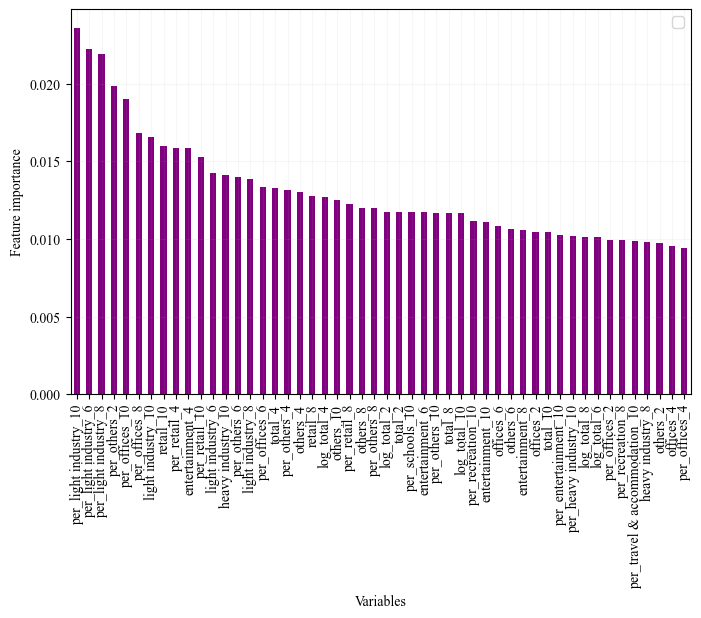

In [22]:
# check the feature importance of random forest
rfc = RandomForestClassifier(random_state = random_state, **best_params)
rfc.fit(X_train, y_train)
feature_importances = pd.DataFrame({'varname': X_train.columns, 'Importance': rfc.feature_importances_}).sort_values(by = 'Importance', ascending = False)
feature_importances.set_index('varname', inplace = True)

ax = feature_importances.head(50).plot(kind = 'bar', rot = 90, figsize = (8, 5), color = 'purple')
ax.set_xlabel('Variables')
ax.set_ylabel('Feature importance')
ax.legend('')
plt.grid(alpha = .1)

In [23]:
shap_values.shape

(732, 130, 7)

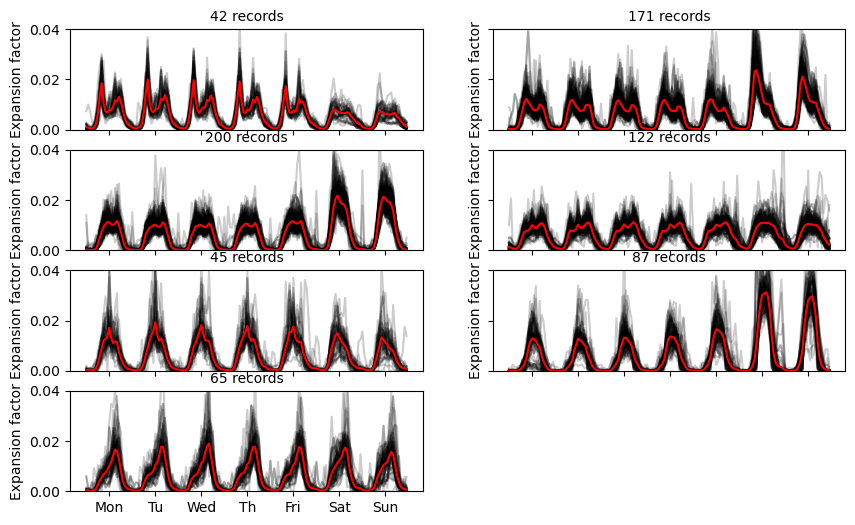

In [28]:
from IPython.display import Image
Image("htw.png")

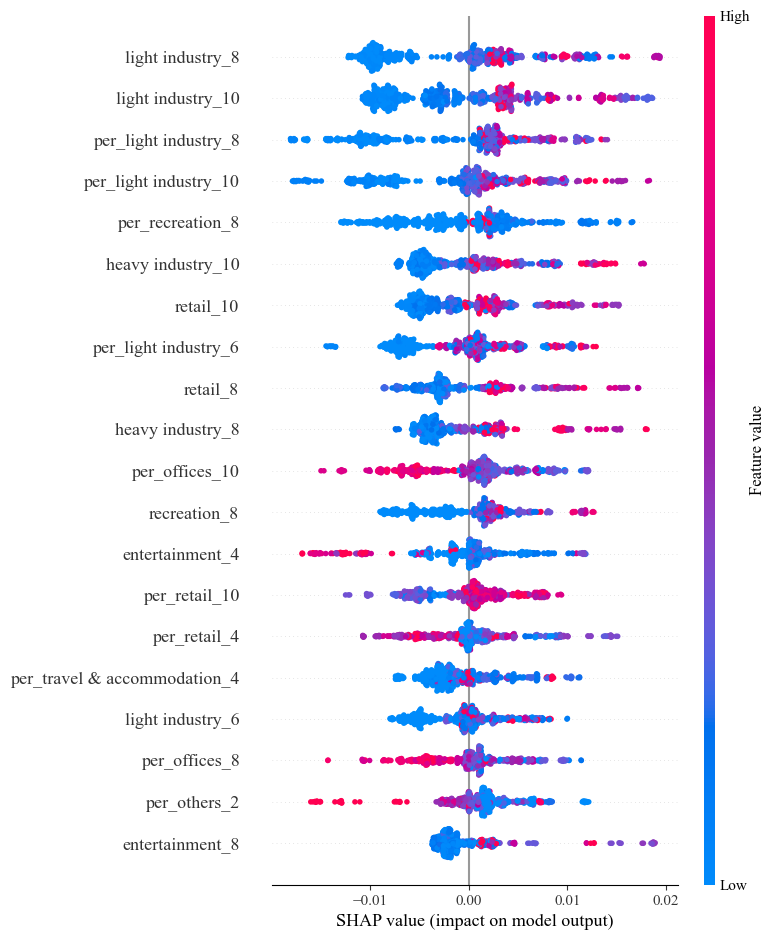

In [33]:
# From left to right, top to bottom (cluster 0 - 6)
# High percentage of schools have a positive impact on belonging to cluster 0, while a high number of entertainment while 400 meter have a negative impact
# High percetage of offices, number of heavy/light industry, total # of POI have a negative impact on belonging to cluster 1, but high percentage of retail have a positve impact
# Trail has a positve impact on belonging to cluster 2, potentially drives the high weekend activity
# High number of entertainment and other businesses has a positive impact on belonging to cluster 3, percentage of offices has a negative impact
# High percentage of offices has a positive impact on belonging to cluster 4
# Low percentage of light industry and high percentage of offices has a positive impact on belonging to cluster 5
# High percentage of retail and heavy industry have a positive impact on belonging to cluster 6
import shap
explainer = shap.TreeExplainer(rfc)
shap_values = explainer(X)
shap.summary_plot(shap_values[:,:,6], X)

### XGBoost

In [18]:
from xgboost import XGBClassifier, plot_importance

In [19]:
xgb = XGBClassifier

params = {
            'max_depth': [i for i in range(2, 151)],
            'n_estimators': [i for i in range(50, 2001, 50)],
            'gamma': [i for i in range(11)],
            'min_child_weight': [i for i in range(10)] 
}

space = {'max_depth': hp.choice("max_depth", params['max_depth']),            
         'n_estimators': hp.choice('n_estimators', params['n_estimators']),
         'gamma': hp.choice('gamma', params['gamma']),                                       # mininum loss reduction required to make a split, similar to pruning
         'min_child_weight' : hp.choice('min_child_weight', params['min_child_weight']),     # minimum sum of weights of all observations required in a child, control overfitting
         'reg_alpha' : hp.uniform('reg_alpha', 0,1),                                         # L1 regularization on weights, high value -> conservative
         'reg_lambda' : hp.uniform('reg_lambda', 0,1),                                       # L2 regularization on weights, high value -> conservative
         'colsample_bytree' : hp.uniform('colsample_bytree', 0,1),                           # the fraction of columns to be subsampled         
        }

best = optimize(xgb, space, n_iter = 100, random_state = random_state, cv = kf, X = X_train, Y = y_train)

100%|█████████████████████████████████████████████| 100/100 [50:20<00:00, 30.20s/trial, best loss: -0.7642258864450373]


In [20]:
print(best)

{'colsample_bytree': 0.6787083464245003, 'gamma': 0, 'max_depth': 55, 'min_child_weight': 7, 'n_estimators': 39, 'reg_alpha': 0.16940401756963902, 'reg_lambda': 0.670636314765005}


In [21]:
best_params

{'class_weight': 'balanced',
 'max_depth': 64,
 'max_features': 'log2',
 'min_samples_leaf': 2,
 'min_samples_split': 8,
 'n_estimators': 1500}

In [22]:
best_params = {key: params[key][value] if key in ['max_depth', 'n_estimators', 'gamma', 'min_child_weight'] else value for key, value in best.items()}
xgb = XGBClassifier
ac_tr_xgb, ac_cv_xgb, ac_tt_xgb = model_performance(X_train = X_train, y_train = y_train, X_test = X_test, y_test = y_test, model = xgb, cv = kf, params = best_params, random_state = random_state)

The prediction accuracy of train set is 94.2%
The confusion matrix is:
[[ 28   0   0   1   0   0   1]
 [  0 140   3   0   0   0   0]
 [  0   6 146   0   1   1   0]
 [  1   0   0  98   0   1   1]
 [  0   1   0   1  29   0   3]
 [  0   0   3   0   1  68   0]
 [  0   3   1   4   0   1  42]]
-----------------------------------------
The prediction accuracy of 10 fold cross-validation is 76.4%
-----------------------------------------
The prediction accuracy of test set is 67.3%
The confusion matrix is:
[[ 9  0  0  2  0  0  1]
 [ 0 22  4  0  1  0  1]
 [ 0  3 35  0  6  2  0]
 [ 1  2  1 14  0  0  3]
 [ 0  2  3  1  3  0  2]
 [ 0  0  4  0  0 11  0]
 [ 0  3  3  2  0  1  5]]


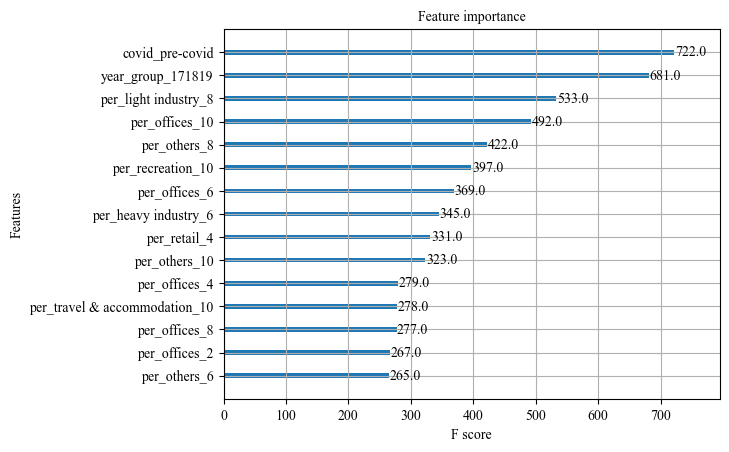

In [23]:
xgb = XGBClassifier(random_state = random_state, **best_params)
xgb.fit(X_train, y_train)
sorted_idx = np.argsort(xgb.feature_importances_)[::-1]
plot_importance(xgb, max_num_features = 15)
plt.show()

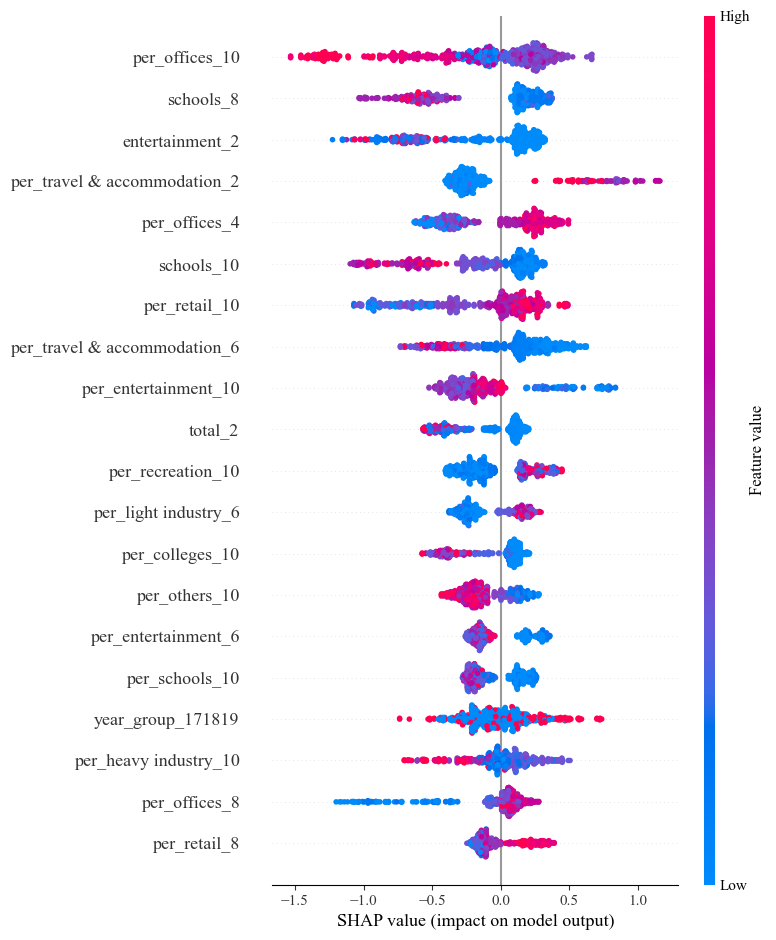

In [52]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X)
shap.summary_plot(shap_values[:,:,1], X)

### Multinomial Logit

In [24]:
import statsmodels.api as sm
from utilClassification import SMWrapperMNL

In [53]:
feature_importances.head(10)

,Importance
varname,
per_light industry_10,0.02
per_light industry_6,0.02
per_light industry_8,0.02
per_others_2,0.02
per_offices_10,0.02
per_offices_8,0.02
light industry_10,0.02
retail_10,0.02
per_retail_4,0.02


In [25]:
var = ['total_4', 
       'per_colleges_10', 'per_schools_10',
       'per_entertainment_4', 'per_recreation_10', 
       'per_retail_6', 
       'per_offices_4', 'per_others_2', 
       'per_travel & accommodation_10', 
       'per_light industry_10', 'per_heavy industry_10',
       'trail', 
#        "year_group_1314", "year_group_1516", "year_group_171819", 'year_group_2021', 
       'year_2013', 'year_2014','year_2015','year_2016','year_2017','year_2018','year_2019','year_2020', 'year_2021', 'year_2022',  
#        "covid_pre-covid", 'covid_covid'
       ]

# var = ['trail', 'schools_10', 'per_light industry_2', 'entertainment_10', 'travel & accommodation_10', 'recreation_8', 
#  'colleges_4', 'heavy industry_10', 'total_10', 'others_10', 'per_retail_2', 'offices_10']

In [26]:
# Check Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['feature'] = var
vif_data['VIF'] = [variance_inflation_factor(X_train[var].values, i) for i in range(len(var))]
print(vif_data)

                          feature       VIF
0                         total_4  1.210512
1                 per_colleges_10  1.140962
2                  per_schools_10  1.758283
3             per_entertainment_4  1.888390
4               per_recreation_10  1.125179
5                    per_retail_6  3.160788
6                   per_offices_4  3.728807
7                    per_others_2  1.912507
8   per_travel & accommodation_10  1.868492
9           per_light industry_10  4.378324
10          per_heavy industry_10  4.980899
11                          trail  3.426208
12                      year_2013  1.236940
13                      year_2014  1.344800
14                      year_2015  1.478254
15                      year_2016  1.574575
16                      year_2017  1.675942
17                      year_2018  1.844869
18                      year_2019  1.761343
19                      year_2020  1.694167
20                      year_2021  1.782279
21                      year_202

In [27]:
X_train[var].describe()

,total_4,per_colleges_10,per_schools_10,per_entertainment_4,per_recreation_10,per_retail_6,per_offices_4,per_others_2,per_travel & accommodation_10,per_light industry_10,...,year_2013,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_2020,year_2021,year_2022
count,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,...,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000
mean,103.232479,0.002604,0.009049,0.104464,0.015859,0.140686,0.312078,0.219525,0.032353,0.032438,...,0.032479,0.044444,0.066667,0.078632,0.090598,0.119658,0.100855,0.099145,0.119658,0.126496
std,364.493114,0.008478,0.011359,0.108928,0.069328,0.098561,0.178804,0.241570,0.038964,0.037325,...,0.177419,0.206257,0.249657,0.269395,0.287283,0.324839,0.301394,0.299113,0.324839,0.332692
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,0.000000,0.000000,0.000000,0.000000,0.086022,0.220588,0.000000,0.013514,0.008547,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,0.000000,0.006079,0.087500,0.004525,0.125581,0.313725,0.200000,0.020710,0.022634,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,88.000000,0.002500,0.011765,0.147059,0.008913,0.194444,0.425926,0.333333,0.033582,0.042584,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3705.000000,0.074214,0.068966,0.500000,0.666667,0.585227,1.000000,1.000000,0.272727,0.250000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [30]:
# Scale data before estimation
scaler = StandardScaler()
scale_columns = var
X_train.loc[:,scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test.loc[:,scale_columns] = scaler.transform(X_test[scale_columns])

In [31]:
mnl = SMWrapperMNL
space = {'alpha': hp.uniform('alpha', 0,1)}
best = optimize(mnl, space, n_iter = 100, random_state = random_state, cv = kf, X = X_train[var], Y = y_train)

Optimization terminated successfully    (Exit mode 0)                                                                  
            Current function value:                                                                                    
1.3396744674671612                                                                                                     
            Iterations:                                                                                                
325                                                                                                                    
            Function evaluations:                                                                                      
326                                                                                                                    
            Gradient evaluations:                                                                                      
325                                     

            Current function value:                                                                                    
1.3979404086663165                                                                                                     
            Iterations:                                                                                                
233                                                                                                                    
            Function evaluations:                                                                                      
234                                                                                                                    
            Gradient evaluations:                                                                                      
233                                                                                                                    
Optimization terminated successfully    

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 6 out of 138 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Iteration limit reached    (Exit mode 9)                                                                               
            Current function value:                                                                                    
1.339328694646777                                                                                                      
            Iterations:                                                                                                
500                                                                                                                    
            Function evaluations:                                                                                      
500                                                                                                                    
            Gradient evaluations:                                                                                      
500                                     

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\l1_solvers_common.py:74: ConvergenceWarning: QC check did not pass for 3 out of 138 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



...

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Iteration limit reached    (Exit mode 9)                                                                               
            Current function value:                                                                                    
1.3097259355781392                                                                                                     
            Iterations:                                                                                                
500                                                                                                                    
            Function evaluations:                                                                                      
500                                                                                                                    
            Gradient evaluations:                                                                                      
500                                     

C:\Users\Qianhua\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Optimization terminated successfully    (Exit mode 0)                                                                  
            Current function value:                                                                                    
1.3568521599495207                                                                                                     
            Iterations:                                                                                                
325                                                                                                                    
            Function evaluations:                                                                                      
326                                                                                                                    
            Gradient evaluations:                                                                                      
325                                     

            Current function value:                                                                                    
1.3287619667588078                                                                                                     
            Iterations:                                                                                                
244                                                                                                                    
            Function evaluations:                                                                                      
244                                                                                                                    
            Gradient evaluations:                                                                                      
244                                                                                                                    
Optimization terminated successfully    

In [32]:
print(best)

{'alpha': 0.522675119192592}


In [33]:
best_params = best
mnl = SMWrapperMNL
ac_tr_mnl, ac_cv_mnl, ac_tt_mnl = model_performance(X_train = X_train[var], y_train = y_train, X_test = X_test[var], y_test = y_test, model = mnl, cv = kf, params = best_params, random_state = random_state)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.3524508174144727
            Iterations: 288
            Function evaluations: 289
            Gradient evaluations: 288
The prediction accuracy of train set is 50.8%
The confusion matrix is:
[[15  8  4  3  0  0  0]
 [ 1 74 50  6  1 10  1]
 [ 4 36 92  8  0 14  0]
 [ 1 10 19 67  0  3  1]
 [ 0  6 14 13  0  1  0]
 [ 1  8 13  1  0 49  0]
 [ 0 15 22 11  0  3  0]]
-----------------------------------------
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.3286783895801562
            Iterations: 388
            Function evaluations: 389
            Gradient evaluations: 388
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.373692834235274
            Iterations: 271
            Function evaluations: 272
            Gradient evaluations: 271
Optimization terminated successfully    (Exit mode 0)
            Current functi

In [34]:
# Train the model
mnl = SMWrapperMNL(random_state = random_state, **best_params)
mnl = mnl.fit(X_train[var], y_train)
print(mnl.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.3524508174144727
            Iterations: 288
            Function evaluations: 289
            Gradient evaluations: 288
                          MNLogit Regression Results                          
Dep. Variable:                  label   No. Observations:                  585
Model:                        MNLogit   Df Residuals:                      459
Method:                           MLE   Df Model:                          120
Date:                Fri, 24 Jan 2025   Pseudo R-squ.:                  0.2685
Time:                        05:21:04   Log-Likelihood:                -764.75
converged:                       True   LL-Null:                       -1045.5
Covariance Type:            nonrobust   LLR p-value:                 3.018e-58
                      label=1       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

### Model Performance

In [36]:
pd.options.display.float_format = '{:.2f}'.format
print(pd.DataFrame({'ac_train': [ac_tr_rfc, ac_tr_xgb, ac_tr_mnl],
                    'ac_cv': [ac_cv_rfc, ac_cv_xgb, ac_cv_mnl],
                    'ac_test': [ac_tt_rfc, ac_tt_xgb, ac_tt_mnl]}).T.rename(columns = {0: 'RFC',
                                                                                       1: 'XGB',
                                                                                       2: 'MNL'}).map('{:.1%}'.format))

            RFC    XGB    MNL
ac_train  83.2%  94.2%  50.8%
ac_cv     77.8%  76.4%  37.1%
ac_test   72.1%  67.3%  42.2%


### Prediction & Expansion

In [23]:
# Get landuse information for shorterm locations
X_shorterm = landuse_information[['short' in id_ for id_ in landuse_information.id]]
X_shorterm.index = X_shorterm.id
print('Out of 557 shorterm locations, {} locations are with landuse information.'.format(len(X_shorterm)))

missing = []
ls = [int(id_.split('_')[0]) for id_ in landuse_information.id if 'short' in id_]
for i in range(1, 558):
    if i not in ls:
        missing.append(i)
print('The locations without landuse information are:', missing)

Out of 557 shorterm locations, 554 locations are with landuse information.
The locations without landuse information are: [241, 275, 490]


In [24]:
# load the short-term count data
miovision_count = pd.read_csv('data/Miovision_short_term_sites_data_combined.csv')
miovision_count_sub = miovision_count[miovision_count.id.isin(X_shorterm.id)]
print('Originally, there are {} short-term counters with daily counts greater than 6 hours. Only {} sites have landuse information.'.format(miovision_count.id.nunique(), miovision_count_sub.id.nunique()))

Originally, there are 461 short-term counters with daily counts greater than 6 hours. Only 458 sites have landuse information.


year
1    436
2     21
3      1
Name: count, dtype: int64
----------------------------------
month
1    467
2     14
Name: count, dtype: int64
----------------------------------
weekno
1    481
2     14
Name: count, dtype: int64


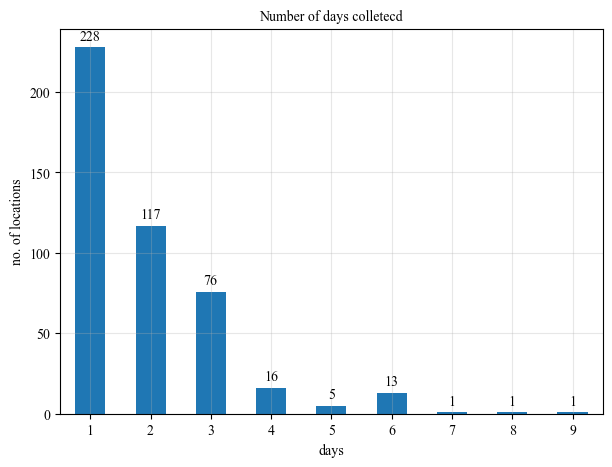

In [44]:
ax = miovision_count_sub.groupby(['id'])['date'].nunique().value_counts().sort_index().plot(kind = 'bar', rot = 0, figsize = (7, 5))
ax.grid(alpha = .3)
ax.set_xlabel('days')
ax.set_ylabel('no. of locations')
for bar in ax.patches:    
    ax.annotate(format(bar.get_height(), '.0f'),
               (bar.get_x() + bar.get_width() / 2, bar.get_height()),
               ha = 'center', va = 'center',
               size = 10, xytext = (0, 8),
               textcoords = 'offset points')
ax.set_title('Number of days colletecd')

print(miovision_count_sub.groupby(['id'])['year'].nunique().value_counts())
print('----------------------------------')
print(miovision_count_sub.groupby(['id', 'year'])['month'].nunique().value_counts())
print('----------------------------------')
print(miovision_count_sub.groupby(['id', 'year', 'month'])['weekno'].nunique().value_counts())

In [25]:
# get site_id-year pairs
site_year_df = miovision_count_sub.groupby(['id', 'year']).nunique().reset_index().rename(columns = {'id': 'site_id'})
# prepare data for prediction
X_shorterm_encoded = data_preparation(site_year_df[['site_id', 'year']], landuse_information)

D:\GSR\PSIP4\utilClassification.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sites_df['trail'] = 0


### Prediction

In [26]:
# Predict hour-to-week cluster membership for each short-term location in different years
prob = rfc.predict_proba(X_shorterm_encoded)

$$ weighted\_ef = \sum_{k=1}^{K}prob_k * ef_k $$

In [27]:
# Calculate the weighted expansion factor for each short-term location
hour_to_week_group_expansion_factor = pd.read_csv('data/hour_to_week_group_expansion_factor.csv')
htw_ef = np.array(hour_to_week_group_expansion_factor)
weighted_ef = pd.DataFrame(np.dot(prob, htw_ef.T))

In [28]:
# reset index of weighted expansion factor dataframe
weighted_ef[['site_id', 'year']] = site_year_df[['site_id', 'year']]
weighted_ef.set_index(['site_id', 'year'], inplace = True)

### Expansion

In [29]:
# get corresponding weighted expansion factor for each hourly count
miovision_count_sub.loc[:,'hour_htw'] = miovision_count_sub['weekday'] * 24 + miovision_count_sub['hour']
miovision_count_sub.loc[:,'weighted_ef'] = miovision_count_sub.apply(lambda x: weighted_ef.loc[(x.id, x.year),x.hour_htw], axis = 1)

C:\Users\Qianhua\AppData\Local\Temp\ipykernel_31252\3591683250.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miovision_count_sub.loc[:,'hour_htw'] = miovision_count_sub['weekday'] * 24 + miovision_count_sub['hour']
C:\Users\Qianhua\AppData\Local\Temp\ipykernel_31252\3591683250.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  miovision_count_sub.loc[:,'weighted_ef'] = miovision_count_sub.apply(lambda x: weighted_ef.loc[(x.id, x.year),x.hour_htw], axis = 1)


In [30]:
# get monthly traffic
total_traffic = miovision_count_sub.groupby(['id', 'year', 'month', 'weekno']).agg({'total_Counts': 'sum', 'weighted_ef': 'sum', 'weekday':'nunique', 'hour_htw': 'nunique'}).reset_index()
total_traffic['weekly_total_traffic'] = total_traffic['total_Counts'] / total_traffic['weighted_ef']

In [31]:
# some locations have collected data in two different weeks within a month
total_traffic.groupby(['id', 'year', 'month'])['weekno'].nunique().sort_values(ascending = False).head(20)

id         year  month
100_short  2013  3        2
302_short  2016  10       2
140_short  2016  7        2
434_short  2014  7        2
499_short  2013  11       2
494_short  2015  2        2
492_short  2016  10       2
276_short  2022  5        2
449_short  2013  7        2
305_short  2016  7        2
401_short  2014  6        2
435_short  2014  7        2
102_short  2015  2        2
181_short  2016  7        2
421_short  2014  8        1
420_short  2014  7        1
415_short  2014  9        1
433_short  2013  7        1
432_short  2014  1        1
431_short  2014  7        1
Name: weekno, dtype: int64

In [32]:
# compute average weekly traffic within a month
total_traffic = total_traffic.groupby(['id', 'year', 'month'])['weekly_total_traffic'].mean().reset_index()

$$ monthly\_total\_traffic = no. of weeks * average\_weekly\_traffic $$

In [33]:
# compute monthly total traffic
total_traffic['num_days'] = total_traffic.apply(lambda x: calendar.monthrange(x.year, x.month)[1], axis = 1)
total_traffic['monthly_total_traffic'] = total_traffic.apply(lambda x: x.num_days/7*x.weekly_total_traffic, axis = 1)

In [34]:
total_traffic.monthly_total_traffic.describe()

count       495.000000
mean       7051.349301
std       13481.635119
min           0.000000
25%         757.979816
50%        2926.733070
75%        7667.120231
max      145112.374368
Name: monthly_total_traffic, dtype: float64

In [35]:
total_traffic.sort_values(by = 'monthly_total_traffic', ascending = False).head(10)

,id,year,month,weekly_total_traffic,num_days,monthly_total_traffic
108,216_short,2014,10,32767.310341,31,145112.374368
451,544_short,2016,1,29965.668711,31,132705.104293
293,392_short,2013,7,21664.001698,31,95940.578949
222,327_short,2016,8,18650.439000,31,82594.801286
107,215_short,2014,10,16899.076246,31,74838.766231
35,142_short,2015,10,13560.076799,31,60051.768680
73,183_short,2014,9,11713.741113,30,50201.747625
277,378_short,2014,3,11308.881702,31,50082.190393
215,320_short,2016,8,11093.464085,31,49128.198089
446,53_short,2013,4,10416.211709,30,44640.907324


In [36]:
miovision_count[(miovision_count.id == '216_short') & (miovision_count.year == 2014) & (miovision_count.month == 10)]

,location,Start Time,total_Counts,lat,long,date,year,month,day,weekno,weekday,hour,id
3477,IC5,2014-10-30 07:00:00,552,37.732465,-122.40558,2014-10-30,2014,10,30,44,3,7,216_short
3478,IC5,2014-10-30 08:00:00,458,37.732465,-122.40558,2014-10-30,2014,10,30,44,3,8,216_short
3479,IC5,2014-10-30 09:00:00,0,37.732465,-122.40558,2014-10-30,2014,10,30,44,3,9,216_short
3480,IC5,2014-10-30 16:00:00,401,37.732516,-122.40558,2014-10-30,2014,10,30,44,3,16,216_short
3481,IC5,2014-10-30 17:00:00,398,37.732516,-122.40558,2014-10-30,2014,10,30,44,3,17,216_short
3482,IC5,2014-10-30 18:00:00,0,37.732516,-122.40558,2014-10-30,2014,10,30,44,3,18,216_short


In [37]:
total_traffic.groupby('month')['monthly_total_traffic'].mean()

month
1     11420.916737
2      5408.162659
3      7466.133507
4     11300.781085
5      4416.266088
6      6088.427519
7      5210.093475
8      6100.302441
9      4929.404677
10     9549.441221
11     8602.233907
12     2694.632196
Name: monthly_total_traffic, dtype: float64

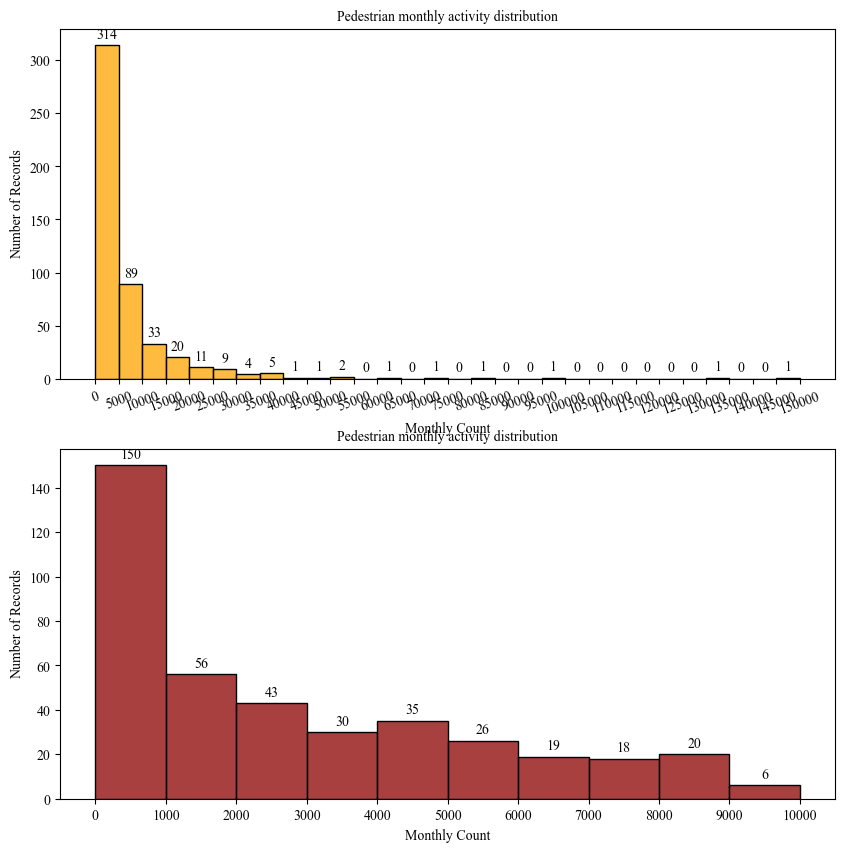

In [41]:
# Most locations don't have too much volumns, but some have 145112 
plt.figure(figsize = (10, 10))
plt.subplot(211)
ax = sns.histplot(total_traffic.monthly_total_traffic, bins = [i * 5000 for i in range(31)], color = 'orange')
ax.set_xticks([i * 5000 for i in range(31)], [i * 5000 for i in range(31)], rotation = 20)
ax.set_xlabel('Monthly Count')
ax.set_ylabel('Number of Records')
ax.set_title('Pedestrian monthly activity distribution')
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), '.0f'),
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha = 'center', va = 'center',
                size = 10, xytext = (0, 8),
                textcoords = 'offset points')

plt.subplot(212)
ax = sns.histplot(total_traffic.monthly_total_traffic, bins = [i * 1000 for i in range(11)], color = 'darkred')
ax.set_xticks([i * 1000 for i in range(11)], [i * 1000 for i in range(11)])
ax.set_xlabel('Monthly Count')
ax.set_ylabel('Number of Records')
ax.set_title('Pedestrian monthly activity distribution')
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), '.0f'),
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha = 'center', va = 'center',
                size = 10, xytext = (0, 8),
                textcoords = 'offset points')

In [87]:
total_traffic.id.nunique()

458

In [120]:
len(total_traffic)

495

In [39]:
total_traffic[['id', 'year', 'month', 'monthly_total_traffic']].to_csv('data/miovision_monthly_total_traffic.csv', index = False)